# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [155]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [156]:
df = pd.read_csv("data/clean_aviation_accidents.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20764 entries, 0 to 20763
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                20764 non-null  str    
 1   Investigation.Type      20764 non-null  str    
 2   Accident.Number         20764 non-null  str    
 3   Event.Date              20764 non-null  str    
 4   Location                20759 non-null  str    
 5   Country                 20757 non-null  str    
 6   Injury.Severity         20045 non-null  str    
 7   Aircraft.Category       20764 non-null  str    
 8   Registration.Number     20595 non-null  str    
 9   Make                    20764 non-null  str    
 10  Model                   20764 non-null  str    
 11  Amateur.Built           20764 non-null  str    
 12  FAR.Description         20412 non-null  str    
 13  Total.Fatal.Injuries    20764 non-null  float64
 14  Total.Serious.Injuries  20764 non-null  float64
 

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [157]:
# Load the cleaned dataset
df = pd.read_csv("data/clean_aviation_accidents.csv")

# Create Total.Onboard column
df["Total.Onboard"] = (
    df["Total.Fatal.Injuries"]
    + df["Total.Serious.Injuries"]
    + df["Total.Minor.Injuries"]
    + df["Total.Uninjured"]
)

# Split aircraft into small and large based on passenger threshold (20)
small_planes = df[df["Total.Onboard"] <= 20]
large_planes = df[df["Total.Onboard"] > 20]

print("Small aircraft:", small_planes.shape)
print("Large aircraft:", large_planes.shape)

Small aircraft: (19852, 20)
Large aircraft: (912, 20)


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [158]:
# Create fatal + serious injury fraction
df["Fatal.Serious.Fraction"] = df["Total.Fatal.Serious"] / df["Total.Onboard"]

# Recreate small and large subsets
small_planes = df[df["Total.Onboard"] <= 20]
large_planes = df[df["Total.Onboard"] > 20]



In [159]:
# Mean fatal/serious injury fraction by make
small_make_safety = (
    small_planes.groupby("Make")[["Fatal.Serious.Fraction"]]
    .mean()
    .sort_values(by="Fatal.Serious.Fraction")
)

large_make_safety = (
    large_planes.groupby("Make")[["Fatal.Serious.Fraction"]]
    .mean()
    .sort_values(by="Fatal.Serious.Fraction")
)

# Keep the 15 safest makes in each group
top_small_makes = small_make_safety.head(15)
top_large_makes = large_make_safety.head(15)

print("Top 15 safest small-aircraft makes:")
print(top_small_makes)

print("\nTop 15 safest large-aircraft makes:")
print(top_large_makes)

Top 15 safest small-aircraft makes:
                                Fatal.Serious.Fraction
Make                                                  
BOMBARDIER INC                                0.090909
MCDONNELL DOUGLAS                             0.094048
BOMBARDIER                                    0.103846
BOEING                                        0.145736
AVIAT AIRCRAFT INC                            0.164474
MAULE                                         0.167816
SWEARINGEN                                    0.194667
AYRES                                         0.200000
GRUMMAN ACFT ENG COR-SCHWEIZER                0.206897
ROCKWELL INTERNATIONAL                        0.212500
AVIAT                                         0.221429
DIAMOND AIRCRAFT IND INC                      0.222973
STINSON                                       0.224138
DEHAVILLAND                                   0.229188
BELLANCA                                      0.229241

Top 15 safest large-aircraft

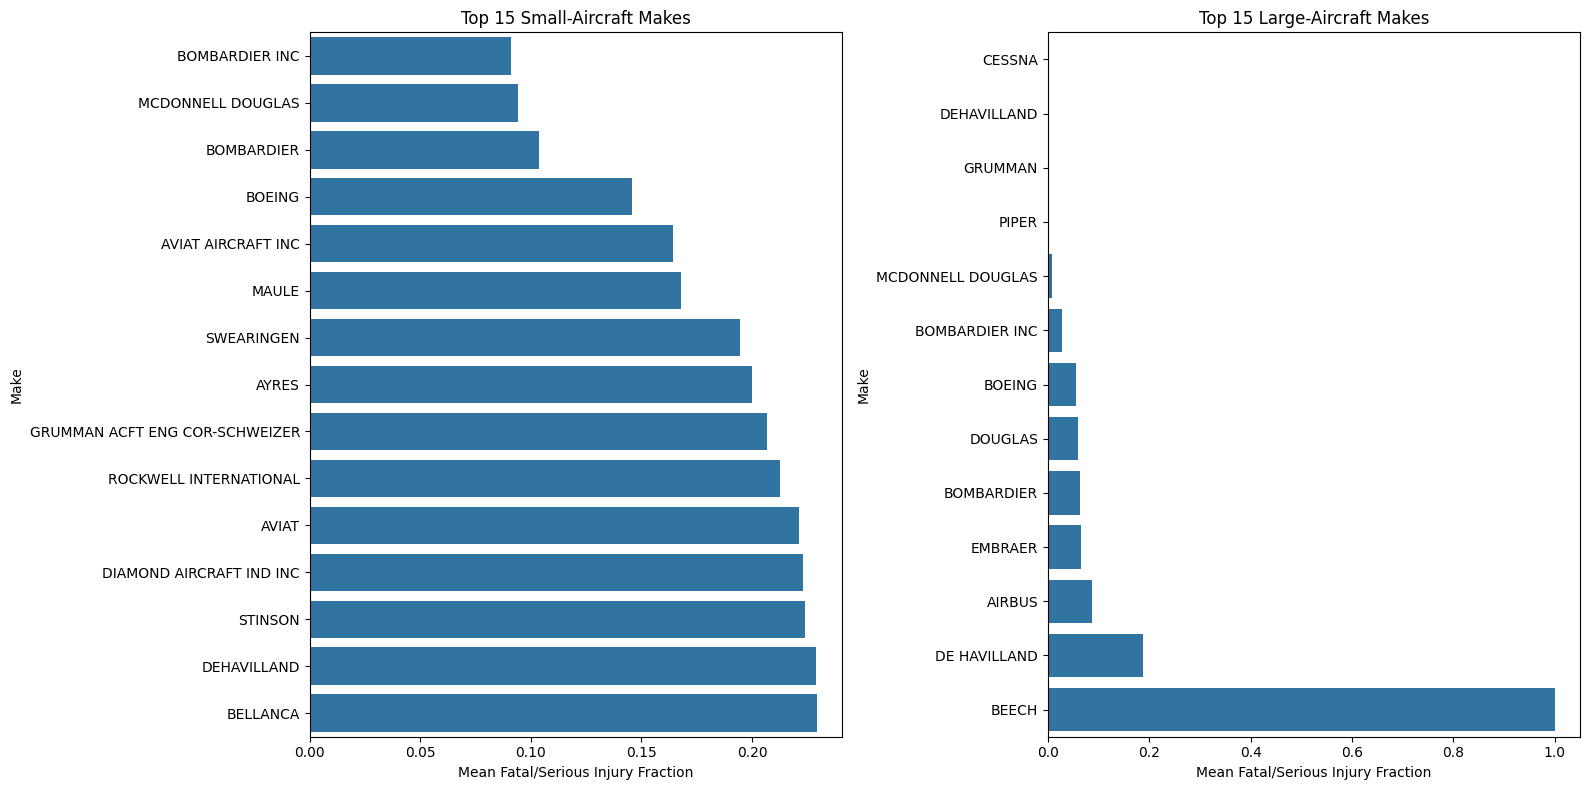

In [160]:
top_small_makes_df = top_small_makes.reset_index()
top_large_makes_df = top_large_makes.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    data=top_small_makes_df,
    x="Fatal.Serious.Fraction",
    y="Make",
    ax=axes[0]
)
axes[0].set_title("Top 15 Small-Aircraft Makes")
axes[0].set_xlabel("Mean Fatal/Serious Injury Fraction")
axes[0].set_ylabel("Make")

sns.barplot(
    data=top_large_makes_df,
    x="Fatal.Serious.Fraction",
    y="Make",
    ax=axes[1]
)
axes[1].set_title("Top 15 Large-Aircraft Makes")
axes[1].set_xlabel("Mean Fatal/Serious Injury Fraction")
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

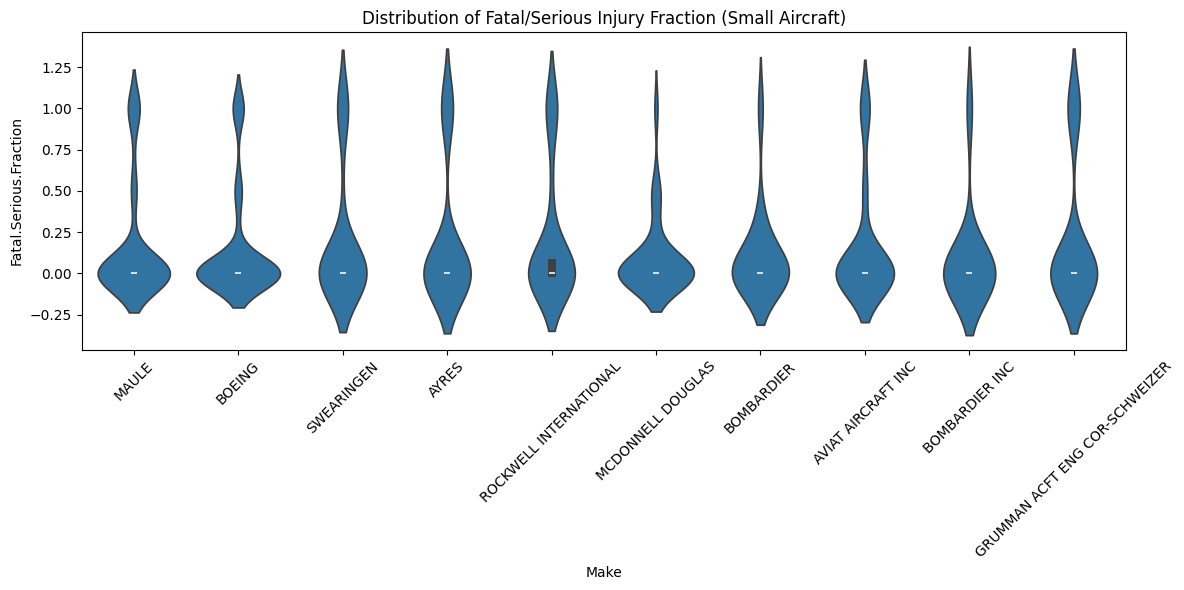

In [161]:
# Get the 10 safest small-aircraft makes
safe_small_makes = top_small_makes.index[:10]

# Filter the dataset
small_subset = small_planes[small_planes["Make"].isin(safe_small_makes)]

plt.figure(figsize=(12,6))

sns.violinplot(
    data=small_subset,
    x="Make",
    y="Fatal.Serious.Fraction"
)

plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction (Small Aircraft)")
plt.tight_layout()

plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

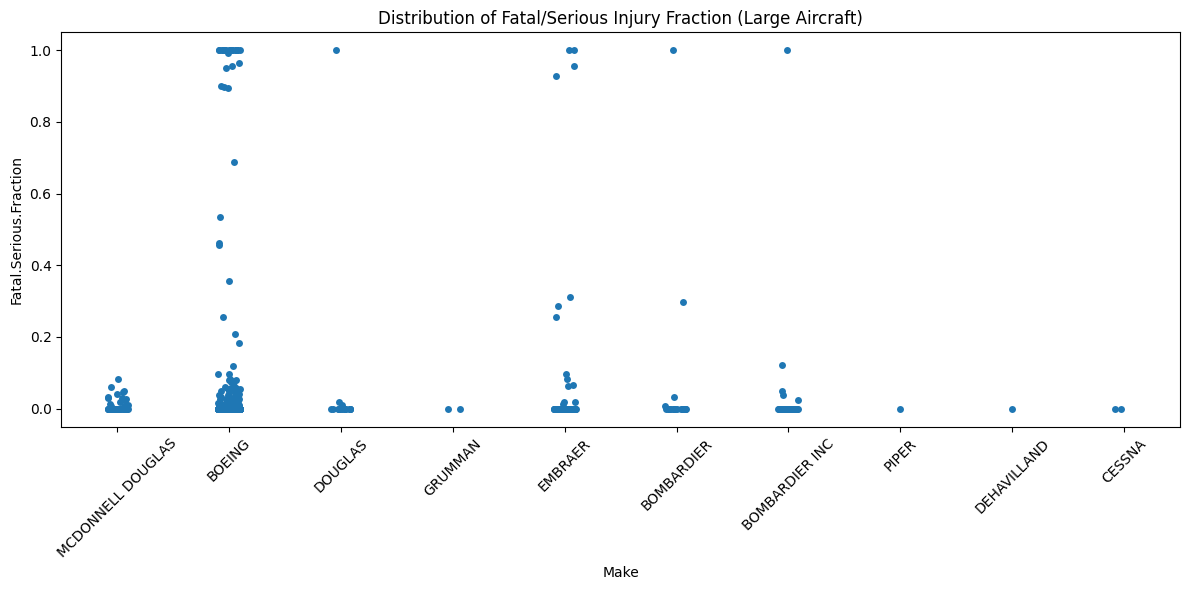

In [162]:
# Get the 10 safest large-aircraft makes
safe_large_makes = top_large_makes.index[:10]

# Filter
large_subset = large_planes[large_planes["Make"].isin(safe_large_makes)]

plt.figure(figsize=(12,6))

sns.stripplot(
    data=large_subset,
    x="Make",
    y="Fatal.Serious.Fraction"
)

plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction (Large Aircraft)")
plt.tight_layout()

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [163]:
# Create destroyed indicator column
df["Destroyed"] = (df["Total.Fatal.Serious"] == df["Total.Onboard"]).astype(int)

small_planes = df[df["Total.Onboard"] <= 20]
large_planes = df[df["Total.Onboard"] > 20]

In [164]:
# Destruction rate for small aircraft
small_destroyed_rate = (
    small_planes.groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)
)

# Destruction rate for large aircraft
large_destroyed_rate = (
    large_planes.groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)
)

print("Lowest destruction rate (small aircraft):")
print(small_destroyed_rate)

print("\nLowest destruction rate (large aircraft):")
print(large_destroyed_rate)

Lowest destruction rate (small aircraft):
Make
MAULE                             0.129310
AVIAT AIRCRAFT INC                0.131579
DEHAVILLAND                       0.148936
STINSON                           0.165517
SWEARINGEN                        0.180000
AVIAT                             0.185714
ROCKWELL INTERNATIONAL            0.196721
DIAMOND AIRCRAFT IND INC          0.202703
BELLANCA                          0.202847
GRUMMAN ACFT ENG COR-SCHWEIZER    0.206897
AERONCA                           0.211454
AMERICAN CHAMPION AIRCRAFT        0.211538
AYRES                             0.214286
TAYLORCRAFT                       0.227273
CESSNA                            0.230058
Name: Destroyed, dtype: float64

Lowest destruction rate (large aircraft):
Make
CESSNA               0.000000
DEHAVILLAND          0.000000
GRUMMAN              0.000000
MCDONNELL DOUGLAS    0.000000
PIPER                0.000000
BOMBARDIER INC       0.023256
EMBRAER              0.025641
BOEING            

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Some aircraft manufacturers tend to have lower fatal or serious injury fractions when accidents occur. For smaller aircraft, manufacturers like Maule, Aviat, and DeHavilland appear to have lower injury severity compared to others.

Based on the destruction rates some manufacturers also show lower chances of the aircraft being completely destroyed in accidents. This could mean aircraft design may play a role in how bad an accident becomes.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Mean fatal/serious injury fraction (large planes):
0.05783292508302397


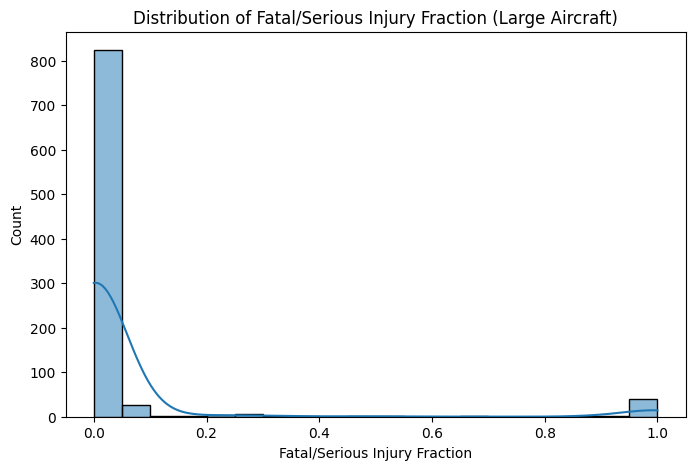

In [165]:
# Mean fatal/serious injury fraction for large planes
large_plane_mean = large_planes["Fatal.Serious.Fraction"].mean()

print("Mean fatal/serious injury fraction (large planes):")
print(large_plane_mean)

plt.figure(figsize=(8,5))

sns.histplot(
    large_planes["Fatal.Serious.Fraction"],
    bins=20,
    kde=True
)

plt.title("Distribution of Fatal/Serious Injury Fraction (Large Aircraft)")
plt.xlabel("Fatal/Serious Injury Fraction")
plt.ylabel("Count")

plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Mean fatal/serious injury fraction (small planes):
0.2808544991006148


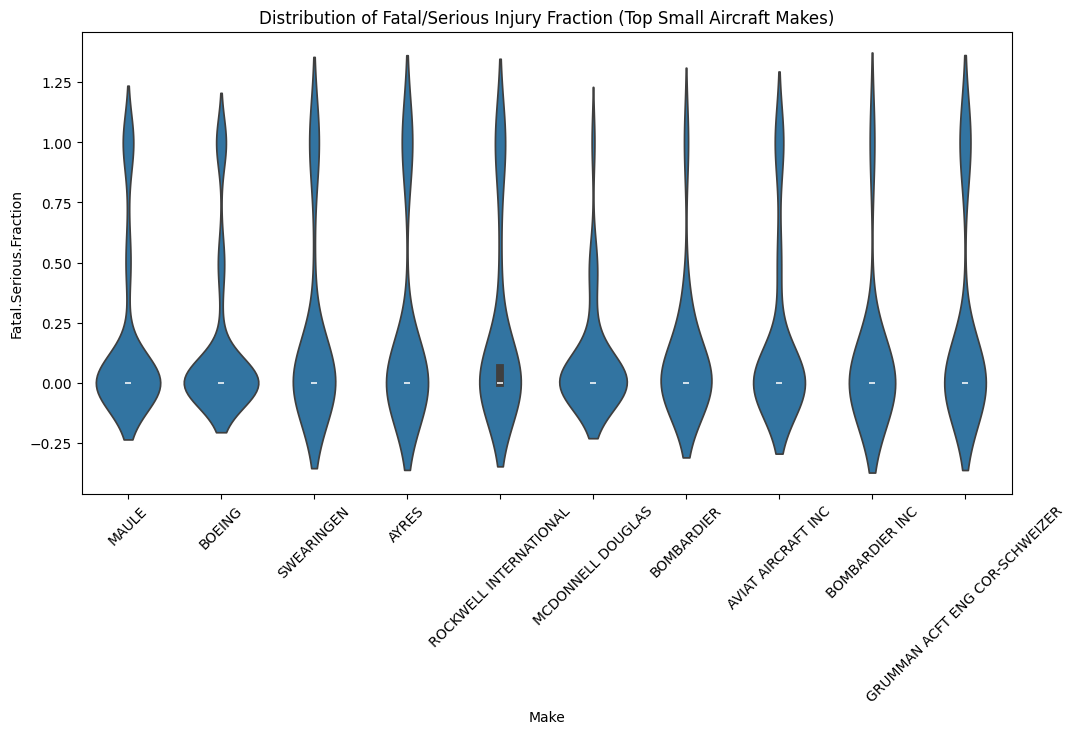

In [166]:
# Mean fatal/serious injury fraction for small planes
small_plane_mean = small_planes["Fatal.Serious.Fraction"].mean()

print("Mean fatal/serious injury fraction (small planes):")
print(small_plane_mean)

safe_small_makes = top_small_makes.index[:10]

small_subset = small_planes[small_planes["Make"].isin(safe_small_makes)]

plt.figure(figsize=(12,6))

sns.violinplot(
    data=small_subset,
    x="Make",
    y="Fatal.Serious.Fraction"
)

plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction (Top Small Aircraft Makes)")
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

The violin plot shows how the fatal or serious injury rate is spread across small aircraft manufacturers. Most of these values are close to 0 meaning many accidents did not result in a high number of fatal injuries compared to the passenger on board.

When comparing these results to larger aircraft earlier in the analysis, larger planes generally show lower fatal or serious injury fractions overall.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Two additional variables that influence accident severity are the number of engines and the phase of flight. Aircraft with more engines generally show slightly lower fatal or serious injury fractions.The phase of flight also has a strong impact on accident severity. Phases such as takeoff and landing tend to show higher injury fractions because aircraft are closer to the ground and operating in more constrained conditions.Overall, the results suggest that both aircraft design factors and operational conditions play a significant role in accident outcomes.